# extract uniform SILCC cube

In [1]:
# extract uniform SILCC cube
import numpy as np
import matplotlib.pyplot as plt
import yt
import pickle
from matplotlib.colors import LogNorm

from astropy import units as u, constants  as c

pc = c.pc.cgs.value
kB  = c.k_B.cgs.value
Msun = c.M_sun.cgs.value
G = c.G.cgs.value
Myr = u.Myr.to("s")
mp = c.m_p.cgs.value

In [2]:
ds = yt.load("SILCC_hdf5_plt_cnt_3000")

yt : [INFO     ] 2026-07-08 14:12:06,696 Parameters: current_time              = 946084486762394.1
yt : [INFO     ] 2026-07-08 14:12:06,696 Parameters: domain_dimensions         = [8 8 8]
yt : [INFO     ] 2026-07-08 14:12:06,697 Parameters: domain_left_edge          = [-7.715e+20 -7.715e+20 -7.715e+20]
yt : [INFO     ] 2026-07-08 14:12:06,697 Parameters: domain_right_edge         = [7.715e+20 7.715e+20 7.715e+20]
yt : [INFO     ] 2026-07-08 14:12:06,698 Parameters: cosmological_simulation   = 0


In [3]:
full = True
if full == True:
    N = 256
    fields = [("gas","number_density"), ("gas","density"), ("gas","temperature"), ("flash","ihp "), 
             ("gas","velocity_x"), ("gas","velocity_y"), ("gas","velocity_z"), 
             ("gas","magnetic_field_x"), ("gas","magnetic_field_y"), ("gas","magnetic_field_z")]
    ofile = "N256-full"
else:
    N = 512
    fields = [("gas","number_density"), ("gas","density"), ("gas","temperature"), ("flash","ihp ")]
    ofile = "N512"
    
left_edge = ds.domain_left_edge
dims = [N, N, N]
# For a uniform covering grid, level=0 is usually enough
level = int(np.round(np.log2(N)))-3
print(level)
cube = ds.covering_grid(level=level,left_edge=left_edge,dims=dims,fields=fields)

data_cooling = {}
data_cooling["n"]     = np.array(cube[("gas","number_density")]).astype(np.float32)
data_cooling["rho"]   = np.array(cube[("gas","density")]).astype(np.float32)
data_cooling["T"]     = np.array(cube[("gas","temperature")]).astype(np.float32)
data_cooling["f_ion"] = np.array(cube[("flash","ihp ")]).astype(np.float32)
if full == True:
    for i, d in enumerate(["x", "y", "z"]):
        data_cooling["vel"+d] = np.array(cube[("gas","velocity_"+d)]).astype(np.float32)
        data_cooling["mag"+d] = np.array(cube[("gas","magnetic_field_"+d)]).astype(np.float32)

for i, d in enumerate(["x", "y", "z"]):
    print(i, d)
    bnds = np.linspace(ds.domain_left_edge[i].to("pc").v, ds.domain_right_edge[i].to("pc").v, N+1)
    bins = 0.5*(bnds[:-1]+bnds[1:])
    data_cooling[d+"_pc_bnds"] = bnds
    data_cooling[d+"_pc"]      = bins
    #print(bins)

with open('../sim-data/SILCC_hdf5_plt_cnt_3000-uniform-cube-'+ofile+'.pkl', 'wb') as handle:
    pickle.dump(data_cooling, handle, protocol=pickle.HIGHEST_PROTOCOL)

5
0 x
1 y
2 z


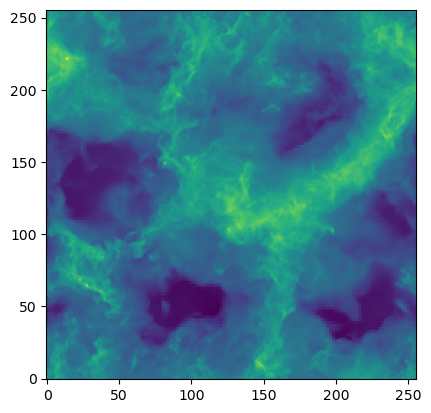

In [4]:
fig, ax = plt.subplots()
ax.imshow(np.sum(data_cooling["rho"],axis=2).T,norm=LogNorm(), origin="lower")

# extract recent SN data

In [5]:
# extract SNe
SNe = np.loadtxt("SNoutput.dat")

In [6]:
t_SNe = SNe[:,0]/Myr

In [7]:
simtime = ds.current_time.to("Myr").v
print(simtime)

29.979608296017254


In [8]:
delta_Myr = 5
#select all SNe between simtime - delat_Myr and simetime
idx = np.where((t_SNe >= simtime - delta_Myr) & (t_SNe <= simtime))
recent_SNe = SNe[idx]
#print(recent_SNe)
# save to file
data = np.array([recent_SNe[:,0]/Myr, recent_SNe[:,1]/pc, recent_SNe[:,2]/pc, recent_SNe[:,3]/pc]).T
print(data.shape)

(69, 4)


In [9]:
#data

In [10]:
np.savetxt("recent_SNe.txt", data, header="time(Myr), x(pc), y(pc), z(pc)")